In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("✓ Libraries loaded successfully.")

# 1. Setup the Database Connection (Engine)
server = r'DESKTOP-J6MHGUQ\SQLEXPRESS01'
database = 'DataWarhouseAnlaytical'
conn_str = f'mssql+pyodbc://{server}/{database}?driver=SQL+Server&Trusted_Connection=yes'
engine = create_engine(conn_str)


✓ Libraries loaded successfully.


In [8]:
query_tables = """
SELECT TABLE_NAME 
FROM INFORMATION_SCHEMA.TABLES 
WHERE TABLE_TYPE = 'BASE TABLE'
"""

tables_df = pd.read_sql(query_tables, conn)
print(tables_df)


C:\Users\shahn\AppData\Local\Temp\ipykernel_22944\2355034477.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables_df = pd.read_sql(query_tables, conn)


           TABLE_NAME
0  gold.dim_customers
1     gold.fact_sales
2   gold.dim_products


### Table Shape & Column Names

In [19]:
df_sales = pd.read_sql("SELECT * FROM [gold.fact_sales]", engine)
df_customers = pd.read_sql("SELECT * FROM [gold.dim_customers]", engine)
df_products = pd.read_sql("SELECT * FROM [gold.dim_products]", engine)
for name, df in [
    ("gold.dim_customers", df_customers),
    ("gold.fact_sales",    df_sales),
    ("gold.dim_products",  df_products)
]:
    print(f"\n{'='*45}")
    print(f"  TABLE: {name}")
    print(f"{'='*45}")
    print(f"  Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
    print("\n  Columns & Data Types:")
    print(df.dtypes.to_string())



  TABLE: gold.dim_customers
  Rows: 18,484   Columns: 10

  Columns & Data Types:
customer_key        int64
customer_id         int64
customer_number    object
first_name         object
last_name          object
country            object
marital_status     object
gender             object
birthdate          object
create_date        object

  TABLE: gold.fact_sales
  Rows: 60,398   Columns: 9

  Columns & Data Types:
order_number     object
product_key       int64
customer_key      int64
order_date       object
shipping_date    object
due_date         object
sales_amount      int64
quantity          int64
price             int64

  TABLE: gold.dim_products
  Rows: 295   Columns: 11

  Columns & Data Types:
product_key        int64
product_id         int64
product_number    object
product_name      object
category_id       object
category          object
subcategory       object
maintenance       object
cost               int64
product_line      object
start_date        object


for name, df in [
    ("gold.dim_customers", df_customers),
    ("gold.fact_sales",    df_sales),
    ("gold.dim_products",  df_products)
]:
    print(f"\n{'='*45}")
    print(f"  TABLE: {name}")
    print(f"{'='*45}")
    print(f"  Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
    print("\n  Columns & Data Types:")
    print(df.dtypes.to_string())

### Missing Values & Duplicates

In [20]:
for name, df in [
    ("gold.dim_customers", df_customers),
    ("gold.fact_sales",    df_sales),
    ("gold.dim_products",  df_products)
]:
    print(f"\n{'='*45}")
    print(f"  TABLE: {name}")
    print(f"{'='*45}")

    missing = df.isnull().sum()
    has_missing = missing[missing > 0]

    if len(has_missing) > 0:
        print("\n  Missing Values:")
        print(has_missing.to_string())
    else:
        print("\n  Missing Values : None found ✓")

    print(f"  Duplicate Rows : {df.duplicated().sum()}")


  TABLE: gold.dim_customers

  Missing Values:
birthdate    17
  Duplicate Rows : 0

  TABLE: gold.fact_sales

  Missing Values:
order_date    19
  Duplicate Rows : 0

  TABLE: gold.dim_products

  Missing Values:
category       7
subcategory    7
maintenance    7
  Duplicate Rows : 0


### Data Cleaning & Missing Value Handling
During the Data Quality Check, I found some missing values across all three tables. Here is my strategy to clean them:

1. **`dim_products` (7 missing in Category, Subcategory, Maintenance):** Since these are categorical text columns, dropping them might lose valuable data. I will replace the missing values with the word **"Unknown"**.
2. **`fact_sales` (19 missing in order_date):** A sales transaction without an order date is useless for time-series analysis. Therefore, I will **drop** these 19 rows.
3. **`dim_customers` (17 missing in birthdate):** Since it's a small number, I will **drop** these rows to keep the demographic analysis accurate.

In [22]:
# 1. Cleaning 'dim_products': Fill missing text values with 'Unknown'
df_products['category'] = df_products['category'].fillna('Unknown')
df_products['subcategory'] = df_products['subcategory'].fillna('Unknown')
df_products['maintenance'] = df_products['maintenance'].fillna('Unknown')

# 2. Cleaning 'fact_sales': Drop rows where 'order_date' is missing
df_sales = df_sales.dropna(subset=['order_date'])

# 3. Cleaning 'dim_customers': Drop rows where 'birthdate' is missing
df_customers = df_customers.dropna(subset=['birthdate'])

# 4. Final Verification
print("=== MISSING VALUES AFTER CLEANING ===")
print(f"dim_products missing values : {df_products.isnull().sum().sum()}")
print(f"fact_sales missing values   : {df_sales.isnull().sum().sum()}")
print(f"dim_customers missing values: {df_customers.isnull().sum().sum()}")
print("\nData is now 100% clean and ready for analysis! ")

=== MISSING VALUES AFTER CLEANING ===
dim_products missing values : 0
fact_sales missing values   : 0
dim_customers missing values: 0

Data is now 100% clean and ready for analysis! 


###  Revenue by Product Category
**Business Question:** Which product categories generate the most revenue for the business? 

To answer this, I am performing a `JOIN` (Merge) between the `fact_sales` and `dim_products` tables using the `product_key`. Then, I will aggregate the total sales amount by category.

In [23]:
# 1. Merging (JOINING) Sales and Products tables using 'product_key'
df_sales_products = pd.merge(df_sales, df_products, on='product_key', how='inner')

# 2. Grouping by 'category' and calculating total revenue
category_revenue = df_sales_products.groupby('category').agg(
    total_revenue=('sales_amount', 'sum')
).reset_index()

# 3. Sorting the results from highest to lowest revenue
category_revenue = category_revenue.sort_values(by='total_revenue', ascending=False)

# Displaying the summarized table
display(category_revenue)

,category,total_revenue
1,Bikes,28311657
0,Accessories,699909
2,Clothing,339692


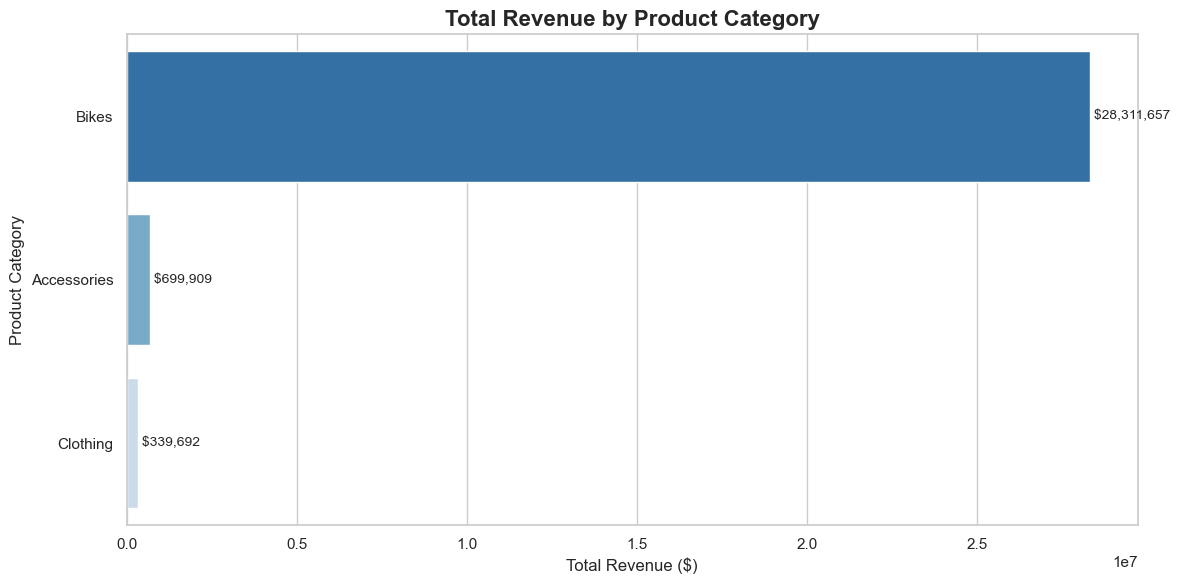

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Creating a horizontal bar chart
sns.barplot(
    data=category_revenue, 
    x='total_revenue', 
    y='category', 
    palette='Blues_r'
)

# Formatting the chart
plt.title('Total Revenue by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

# Adding data labels (numbers) to the bars
for index, value in enumerate(category_revenue['total_revenue']):
    plt.text(value, index, f' ${value:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Customer Demographics: Sales by Age Group
**Business Question:** Which age group generates the most revenue? Should the marketing team target a specific age demographic?

To analyze this, I will merge the `fact_sales` and `dim_customers` tables. I will calculate the current age of each customer using their `birthdate`, group them into logical age brackets (e.g., 18-25, 26-35), and calculate the revenue for each group.

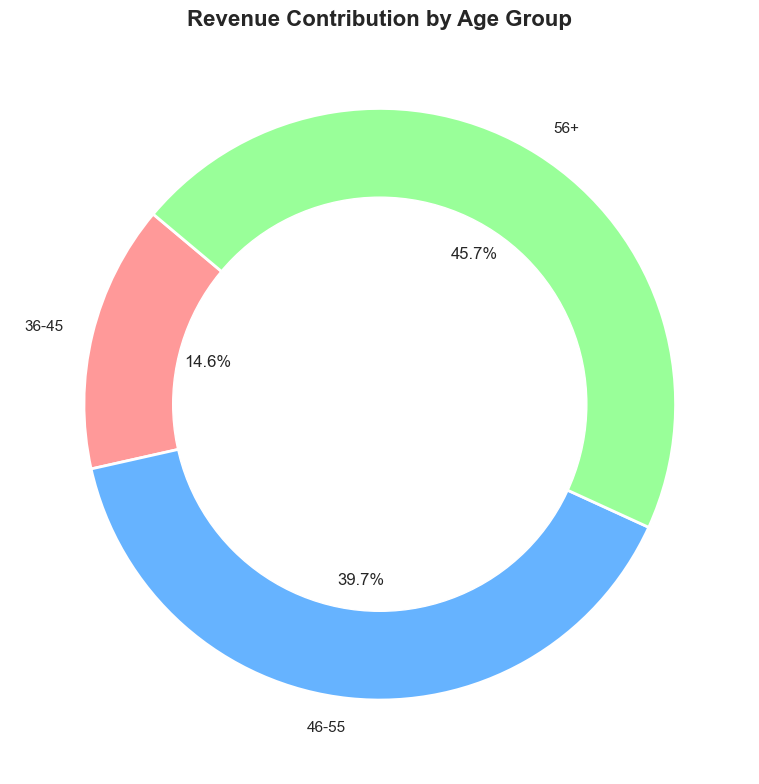

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# 1. Merging Sales and Customers tables
df_sales_customers = pd.merge(df_sales, df_customers, on='customer_key', how='inner')

# 2. Calculating Customer Age
df_sales_customers['birthdate'] = pd.to_datetime(df_sales_customers['birthdate'])
current_year = datetime.now().year
df_sales_customers['Age'] = current_year - df_sales_customers['birthdate'].dt.year

# 3. Creating Age Groups
bins = [0, 25, 35, 45, 55, 150]
labels = ['Under 25', '26-35', '36-45', '46-55', '56+']
df_sales_customers['Age_Group'] = pd.cut(df_sales_customers['Age'], bins=bins, labels=labels)

# 4. Aggregating Revenue by Age Group
age_group_revenue = df_sales_customers.groupby('Age_Group', observed=True).agg(
    total_revenue=('sales_amount', 'sum')
).reset_index()

# 5. Creating the Donut Chart
plt.figure(figsize=(8, 8))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']

plt.pie(
    age_group_revenue['total_revenue'], 
    labels=age_group_revenue['Age_Group'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Drawing a white circle in the middle to make it a 'Donut'
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Formatting
plt.title('Revenue Contribution by Age Group', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Sales Trend Over Time (Time-Series Analysis)
**Business Question:** How is our revenue trending over time? Are there any specific months with peak sales (seasonality)?

To answer this, I will extract the year and month from the `order_date` in the `fact_sales` table and aggregate the total revenue to visualize the growth trend over time.

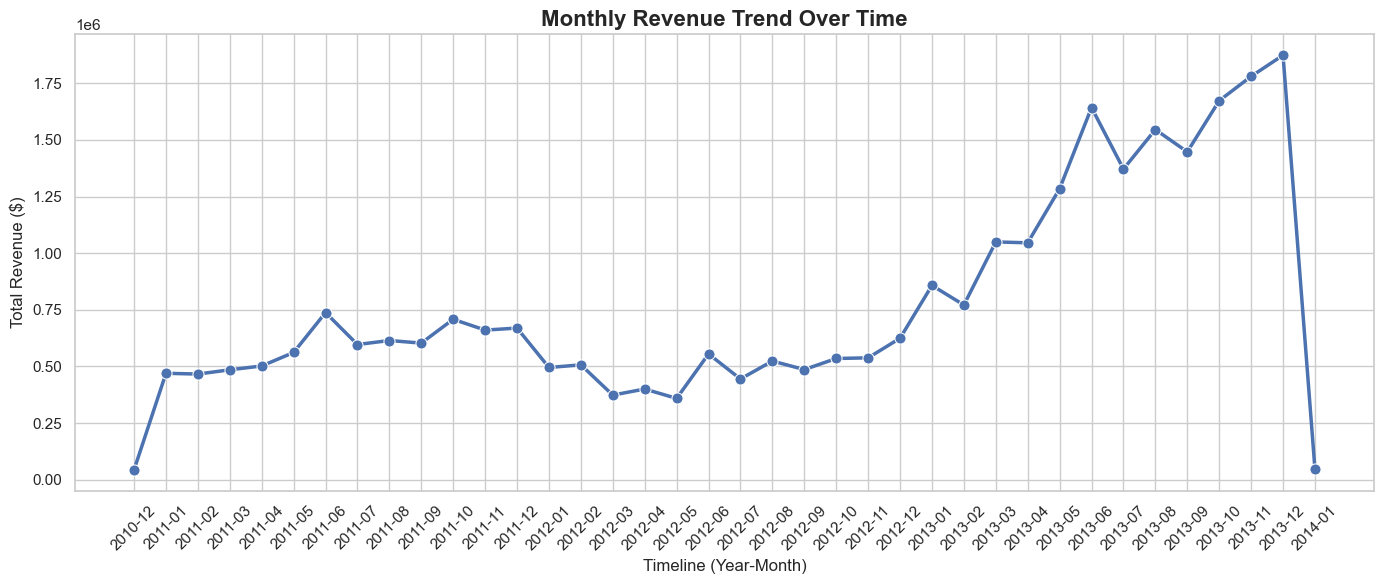

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert 'order_date' to properly formatted datetime
df_sales['order_date'] = pd.to_datetime(df_sales['order_date'])

# 2. Extract Year and Month into a new column (Format: YYYY-MM)
df_sales['Year_Month'] = df_sales['order_date'].dt.to_period('M').astype(str)

# 3. Group by the new 'Year_Month' column and calculate total revenue
monthly_trend = df_sales.groupby('Year_Month').agg(
    total_revenue=('sales_amount', 'sum')
).reset_index()

# 4. Sort the data chronologically
monthly_trend = monthly_trend.sort_values('Year_Month')

# 5. Create the Line Chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_trend, 
    x='Year_Month', 
    y='total_revenue', 
    marker='o', 
    color='b', 
    linewidth=2.5, 
    markersize=8
)

# 6. Formatting the chart
plt.title('Monthly Revenue Trend Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Timeline (Year-Month)', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45) # Rotating x-axis labels so they don't overlap
plt.tight_layout()

# Displaying the chart
plt.show()

### Executive Summary & Business Recommendations
Based on the end-to-end data analysis of the sales, customer, and product data, here are the key findings and strategic recommendations for the business:

### 1. Key Findings:
* **Primary Target Audience:** Customers aged **56 and above** are the highest revenue contributors, generating the majority of the sales.
* **Top Revenue Generator:** The **Product Category [Insert Your Top Category Name here]** is driving the most revenue for the company.
* **Peak Sales Season:** The business experienced its highest-ever historical sales peak in **January 2014 (2014-01)**, indicating high demand during the New Year/winter season.

### 2. Strategic Recommendations:
* **Tailored Marketing:** Focus marketing budgets on campaigns targeting the senior demographic (56+). Ensure promotional materials are highly readable and accessible.
* **Inventory Management:** Stock up on the best-selling product categories prior to the winter season (November–December) to fully capitalize on the January sales spike.
* **Customer Retention:** Create a loyalty program specifically designed for older demographics to increase their repeat purchase rate.
